<a href="https://colab.research.google.com/github/Glaze0/Assignment/blob/main/BayesThm_Distributions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

## Viz Helpers

In [ ]:
# === DATA + PICTURE HELPERS — run this cell, then ignore it ========
COLORS = ["#2563eb", "#e07b39", "#3f9c7c"]

def load_uber(seed=11):
    "One month of Uber rides (simulated for teaching, not real company data)."
    rng = np.random.default_rng(seed)
    slots = 24 * 30                                    # 720 hourly slots in a month
    per_slot = rng.poisson(6, slots)                   # rides arriving each hour
    hour_slot = np.repeat(np.arange(slots), per_slot)
    n = len(hour_slot)
    hour = hour_slot % 24
    peak = np.isin(hour, [8, 9, 10, 17, 18, 19])
    trip = np.clip(rng.normal(24, 6, n), 4, None).round(1)
    fare = 45 + 11 * trip + rng.normal(0, 25, n)
    surge = rng.random(n) < 0.02
    fare = np.where(surge, fare * rng.uniform(2.0, 2.8, n), fare)
    cancelled = (rng.random(n) < np.where(peak, 0.20, 0.08)).astype(int)
    fraud = (rng.random(n) < 0.01).astype(int)
    flagged = (rng.random(n) < np.where(fraud == 1, 0.90, 0.05)).astype(int)
    return pd.DataFrame({
        "hour_slot":    hour_slot,                     # which hour of the month
        "hour":         hour,
        "is_peak":      peak.astype(int),
        "trip_minutes": trip,
        "fare":         fare.round(2),
        "surge":        surge.astype(int),
        "cancelled":    cancelled,
        "is_fraud":     fraud,
        "flagged":      flagged})

def _axes(title, xlabel, ylabel, size=(6, 4)):
    fig, ax = plt.subplots(figsize=size)
    ax.set_title(title, fontsize=11, loc="left")
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.grid(True, axis="y", color="#e8e8e8"); ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    return ax

def show_hist(values, title, xlabel, marks=None, bins=40):
    ax = _axes(title, xlabel, "number of rides")
    ax.hist(values, bins=bins, color=COLORS[0], alpha=0.85)
    for i, (name, v) in enumerate((marks or {}).items()):
        ax.axvline(v, color=COLORS[i % 2 + 1], lw=2, ls="--")
        ax.annotate(f"{name} = {v:.1f}", (v, ax.get_ylim()[1] * (0.92 - 0.1 * i)),
                    xytext=(9, 0), textcoords="offset points",
                    color=COLORS[i % 2 + 1], fontsize=9)
    plt.show()

def show_bars(labels, values, title, ylabel, baseline=None, baseline_label=""):
    ax = _axes(title, "", ylabel)
    ax.bar([str(l) for l in labels], values, color=COLORS[0], width=0.55)
    for x, v in enumerate(values):
        ax.annotate(f"{v:.3f}", (x, v), xytext=(0, 4), textcoords="offset points",
                    ha="center", fontsize=9)
    if baseline is not None:
        ax.axhline(baseline, color=COLORS[1], lw=2, ls="--")
        ax.annotate(baseline_label, (len(values) - 1, baseline), xytext=(0, 9),
                    textcoords="offset points", ha="right", color=COLORS[1], fontsize=9)
    ax.margins(y=0.20); plt.show()

def show_fit(observed, predicted_x, predicted_p, title, xlabel):
    "Bars = what actually happened.  Dots = what the distribution predicts."
    ax = _axes(title, xlabel, "share of cases")
    seen = pd.Series(observed).value_counts(normalize=True).sort_index()
    ax.bar(seen.index, seen.values, color=COLORS[0], width=0.7, label="what we observed")
    ax.plot(predicted_x, predicted_p, "o", color=COLORS[1], ms=8,
            label="what the formula predicts")
    ax.legend(frameon=False, fontsize=9); plt.show()

## Probability

In [ ]:
df = load_uber()
print("Uber ride file loaded:", len(df), "rides")

Uber ride file loaded: 4328 rides


In [ ]:
df.shape

(4328, 9)

In [ ]:
df.head()

,hour_slot,hour,is_peak,trip_minutes,fare,surge,cancelled,is_fraud,flagged
0,0,0,0,30.6,425.04,0,0,0,0
1,0,0,0,27.7,326.40,0,0,0,0
2,0,0,0,23.8,281.49,0,0,0,0
3,1,1,0,16.0,253.05,0,0,0,0
4,1,1,0,21.3,305.81,0,0,0,0


In [ ]:
df['cancelled'].sum()

np.int64(469)

In [ ]:
print("cancelled        :", df["cancelled"].sum())
print("flagged by system:", df["flagged"].sum())
print("actually fraud   :", df["is_fraud"].sum())

cancelled        : 469
flagged by system: 270
actually fraud   : 44


In [ ]:
# A : a ride is cancelled.
# P(A)

print("P(cancelled) =", round(df["cancelled"].mean(), 3))

P(cancelled) = 0.108


In [ ]:
# df["is_peak"].mean()

In [ ]:
peak_rides = df[df['is_peak'] == 1]
print("rush-hour rides         :", len(peak_rides))
print("P(cancelled | peak hour) :", round(peak_rides["cancelled"].mean(), 3))

rush-hour rides         : 1064
P(cancelled | peak hour) : 0.178


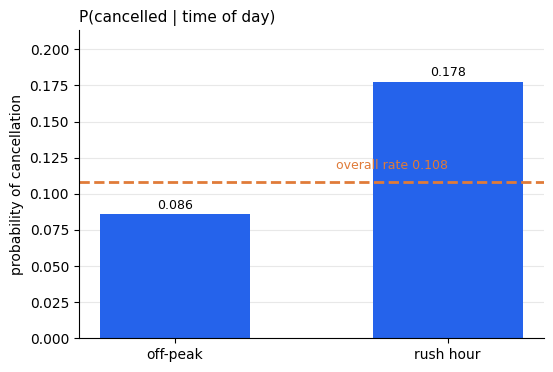

In [ ]:
by_peak = df.groupby("is_peak")["cancelled"].mean()

show_bars(["off-peak", "rush hour"], by_peak.values,
          "P(cancelled | time of day)", "probability of cancellation",
          baseline=df["cancelled"].mean(), baseline_label="overall rate 0.108")

In [ ]:
# P(ride is cancelled | peak hour) = P(peak hour | ride is cancelled )
# P(A|B) = P(B|A)

In [ ]:
# P(peak hour | ride is cancelled )

df[df['cancelled'] == 1]['is_peak'].mean()

np.float64(0.40298507462686567)

In [ ]:
print("P(cancelled | peak) =", round(df[df["is_peak"] == 1]["cancelled"].mean(), 3))
print("P(peak | cancelled) =", round(df[df["cancelled"] == 1]["is_peak"].mean(), 3))

P(cancelled | peak) = 0.178
P(peak | cancelled) = 0.403


## Bayes Theorem
- The system flagged 270 rides.
**How many are really fraud?**

In [ ]:
df['is_fraud'].mean()

np.float64(0.010166358595194085)

In [ ]:
# P( fraud | flagged)

In [ ]:
prior       = df["is_fraud"].mean()                         # how common fraud is
hit_rate    = df[df["is_fraud"] == 1]["flagged"].mean()     # catches real fraud
false_alarm = df[df["is_fraud"] == 0]["flagged"].mean()     # alerts on honest rides

print("P(fraud)              =", round(prior, 4))
print("P(flagged | fraud)    =", round(hit_rate, 3))
print("P(flagged | no fraud) =", round(false_alarm, 3))

P(fraud)              = 0.0102
P(flagged | fraud)    = 0.909
P(flagged | no fraud) = 0.054


In [ ]:
evidence = hit_rate*prior + false_alarm*(1-prior)
print("P(flagged) =", round(evidence, 4))

P(flagged) = 0.0624


In [ ]:
posterior = hit_rate * prior / evidence
print("P(fraud | flagged) =", round(posterior, 3))

P(fraud | flagged) = 0.148


| Term | Name | Meaning here |
|---|---|---|
| `P(fraud)` | **prior** | how common fraud is before you look at any alert |
| `P(flagged \| fraud)` | **likelihood** | how good the system is at catching real fraud |
| `P(flagged)` | **evidence** | how often the system alerts at all |
| `P(fraud \| flagged)` | **posterior** | **what we actually want to know** |

In [ ]:
# A disease affects 1% of the population.
# A test has a 5% false positive rate. P(positve|not infected) = 0.05
# and is 95%  correctly identifies. P(positve|infected) = 0.95
# If a patient tests positive,
# what is the probability they actually have the disease?

| Where you meet this | The updated belief |
|---|---|
| Spam filters | P(spam \| contains "winner") |
| Medical tests | P(disease \| positive result) |
| Fraud detection | P(fraud \| flagged) — today |
| Naive Bayes classifiers | Bayes applied to many clues at once |

## Distributions

In [ ]:
# df['trip_minutes']

In [ ]:
# sns.histplot( df['trip_minutes'])

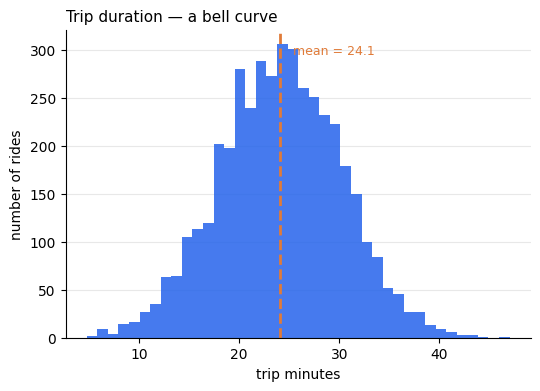

In [ ]:
show_hist(df["trip_minutes"], "Trip duration — a bell curve", "trip minutes",
          marks={"mean": df["trip_minutes"].mean()})

In [ ]:
df["trip_minutes"].std()

6.084734182965612

In [ ]:
print((df["trip_minutes"].mean()))
print(np.median(df["trip_minutes"]))

24.120702402957484
24.2


In [ ]:
df['trip_minutes'].skew()

np.float64(-0.014438611432901491)

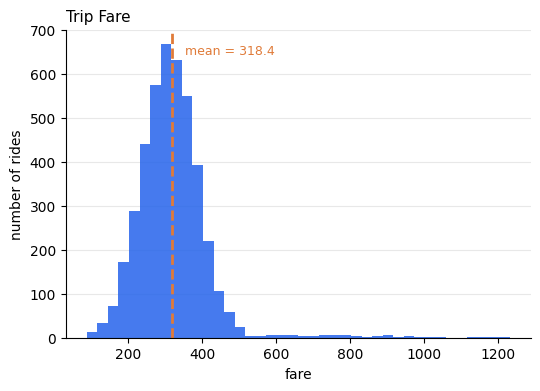

In [ ]:
show_hist(df["fare"], "Trip Fare", "fare",
          marks={"mean": df["fare"].mean()})

In [ ]:
df['fare'].skew()

np.float64(2.638956542516529)

In [ ]:
trips = df["trip_minutes"]
mu = df["trip_minutes"].mean()
sig = df["trip_minutes"].std()

((trips > (mu -2*sig)) & (trips < (mu + 2*sig))).mean() #

np.float64(0.9530961182994455)

In [ ]:
((trips > (mu -1*sig)) & (trips < (mu + 1*sig))).mean()

np.float64(0.683456561922366)

In [ ]:
((trips > (mu -3*sig)) & (trips < (mu + 3*sig))).mean()

np.float64(0.9981515711645101)

In [ ]:
# how many rides can one driver finish in 60 minutes?

In [ ]:
stats.norm.cdf(30, loc= 24, scale=6)

np.float64(0.8413447460685429)

In [ ]:
stats.norm.cdf(32, loc=24, scale=6)

np.float64(0.9087887802741321)

In [ ]:
1 - stats.norm.cdf(38, loc=24, scale=6)

np.float64(0.009815328628645315)

In [ ]:
stats.norm.ppf(0.908, loc=24, scale=6)

np.float64(31.971235973140857)

In [ ]:
stats.norm.ppf(0.95, loc=24, scale=6)

np.float64(33.86912176170883)

In [ ]:
# how many rides can one driver finish in 60 minutes?

In [ ]:
slow_trip  = stats.norm.ppf(0.95, loc=24, scale=6)
slow_trip

np.float64(33.86912176170883)

In [ ]:
per_driver = 60/slow_trip
print("a slow trip (95th percentile):", round(slow_trip, 1), "minutes")
print("rides one driver can clear   :", round(per_driver, 2), "per hour")

a slow trip (95th percentile): 33.9 minutes
rides one driver can clear   : 1.77 per hour


In [ ]:
60/24 # -> only true for 50% of the driver

2.5

In [ ]:
# my 95% of drivers completes 1.77 trips per hour

## Binomial
- A driver takes **20 ride requests** in a shift. How many get cancelled?

In [ ]:
p_cancel = df["cancelled"].mean()
n_rides = 20
print("P(cancel) per ride    :", round(p_cancel, 3))
print("P(exactly 3 cancel)   :", round(stats.binom.pmf(3, n_rides, p_cancel), 3))
print("P(exactly 2 cancel)   :", round(stats.binom.pmf(2, n_rides, p_cancel), 3))
print("P(exactly 1 cancel)   :", round(stats.binom.pmf(1, n_rides, p_cancel), 3))

P(cancel) per ride    : 0.108
P(exactly 3 cancel)   : 0.206
P(exactly 2 cancel)   : 0.283
P(exactly 1 cancel)   : 0.245


In [ ]:
print("P(cancel<=3)   :", round(stats.binom.cdf(3, n_rides, p_cancel), 3))

P(cancel<=3)   : 0.836
